### Importing Libraries

In [94]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [95]:
train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

In [96]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [97]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [98]:
train_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [99]:
print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

Training Dataset Shape: (614, 13)
Testing Dataset Shape: (367, 12)


In [100]:
print("Training Dataset Columns:")
print(train_data.columns)

print("\nTesting Dataset Columns:")
print(test_data.columns)

Training Dataset Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Testing Dataset Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')


### Data Cleaning

In [101]:
train_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [102]:
test_data.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [103]:
print("Duplicates in Training Dataset:", train_data.duplicated().sum())
print("Duplicates in Testing Dataset:", test_data.duplicated().sum())

Duplicates in Training Dataset: 0
Duplicates in Testing Dataset: 0


In [104]:
categorical_columns = train_data.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}")
    print(train_data[column].unique())


Loan_ID
<ArrowStringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str

Gender
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Married
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Dependents
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

Education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Self_Employed
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Property_Area
<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

Loan_Status
<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


C:\Users\LAKSHDEEP\AppData\Local\Temp\ipykernel_2576\3304820262.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train_data.select_dtypes(include='object').columns


In [105]:
train_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

## EDA

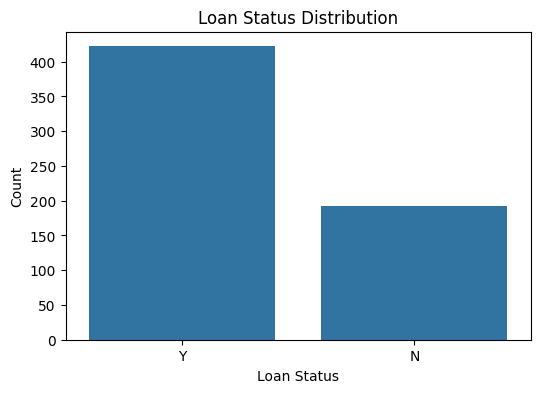

In [106]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=train_data)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

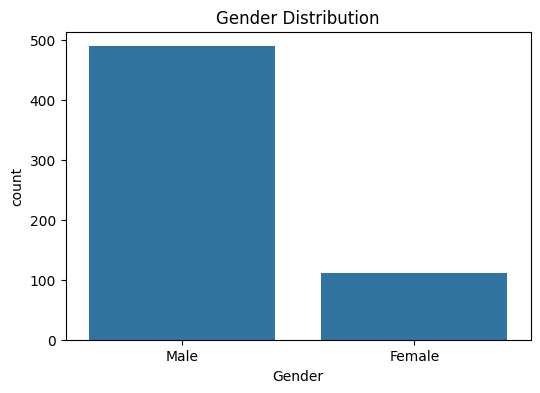

In [107]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=train_data)

plt.title("Gender Distribution")
plt.show()

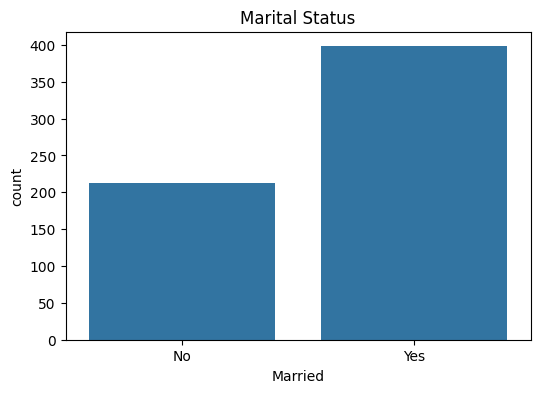

In [108]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', data=train_data)

plt.title("Marital Status")
plt.show()

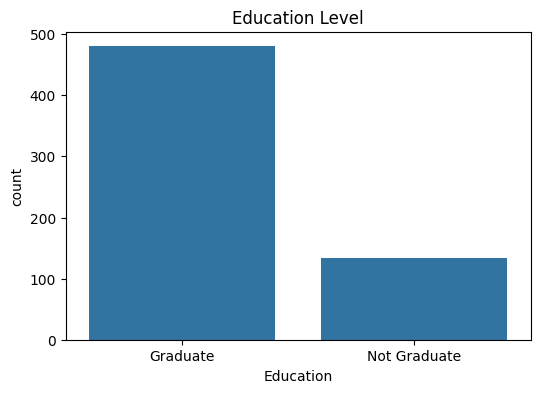

In [109]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=train_data)

plt.title("Education Level")
plt.show()

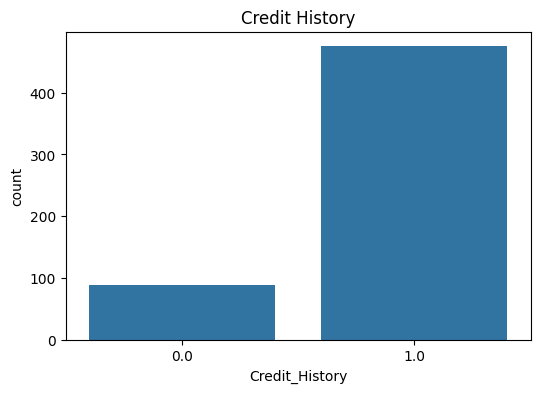

In [110]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', data=train_data)

plt.title("Credit History")
plt.show()

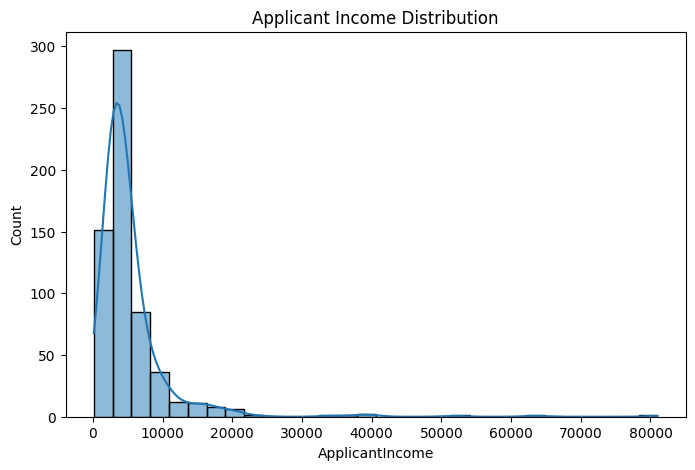

In [111]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['ApplicantIncome'], bins=30, kde=True)

plt.title("Applicant Income Distribution")
plt.show()

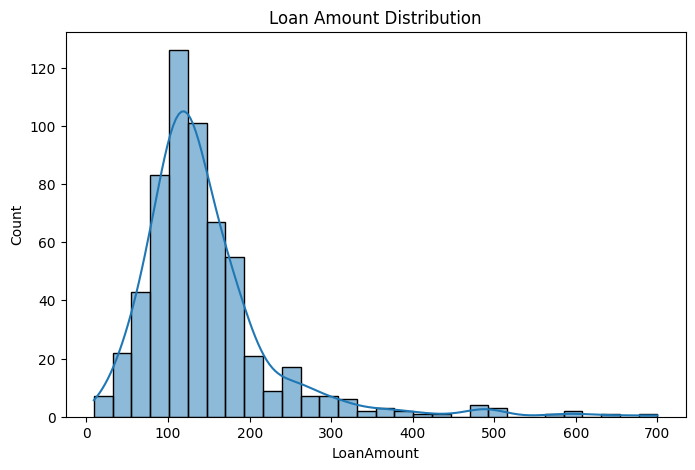

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['LoanAmount'], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.show()

### Data Preprocessing

In [113]:
from sklearn.preprocessing import LabelEncoder

In [114]:
train_data.fillna({
    'Gender': train_data['Gender'].mode()[0],
    'Married': train_data['Married'].mode()[0],
    'Dependents': train_data['Dependents'].mode()[0],
    'Self_Employed': train_data['Self_Employed'].mode()[0],
    'LoanAmount': train_data['LoanAmount'].median(),
    'Loan_Amount_Term': train_data['Loan_Amount_Term'].mode()[0],
    'Credit_History': train_data['Credit_History'].mode()[0]
}, inplace=True)

test_data.fillna({
    'Gender': test_data['Gender'].mode()[0],
    'Married': test_data['Married'].mode()[0],
    'Dependents': test_data['Dependents'].mode()[0],
    'Self_Employed': test_data['Self_Employed'].mode()[0],
    'LoanAmount': test_data['LoanAmount'].median(),
    'Loan_Amount_Term': test_data['Loan_Amount_Term'].mode()[0],
    'Credit_History': test_data['Credit_History'].mode()[0]
}, inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,1.0,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [115]:
encoder = LabelEncoder()

cols = ['Gender','Married','Dependents','Education',
        'Self_Employed','Property_Area','Loan_Status']

for col in cols:
    train_data[col] = encoder.fit_transform(train_data[col])

cols_test = ['Gender','Married','Dependents',
             'Education','Self_Employed','Property_Area']

for col in cols_test:
    test_data[col] = encoder.fit_transform(test_data[col])

In [116]:
test_ids = test_data['Loan_ID']

In [117]:
train_data.drop('Loan_ID', axis=1, inplace=True)
test_data.drop('Loan_ID', axis=1, inplace=True)

## Model Building

In [118]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [119]:
# Split Features and Target
X = train_data.drop('Loan_Status', axis=1)
y = train_data['Loan_Status']

In [120]:
# Split Training Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression

In [121]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7886178861788617


C:\Users\LAKSHDEEP\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## KNN

In [122]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.5772357723577236


## Decision Tree

In [123]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6910569105691057


## Random Forest

In [124]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7560975609756098


### Comparing Accuracy Of Models

In [125]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("KNN:", accuracy_score(y_test, knn_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.7886178861788617
KNN: 0.5772357723577236
Decision Tree: 0.6910569105691057
Random Forest: 0.7560975609756098


## Classification Report

In [126]:
print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("KNN")
print(classification_report(y_test, knn_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

KNN
              precision    recall  f1-score   support

           0       0.24      0.09      0.13        43
           1       0.63      0.84      0.72        80

    accuracy                           0.58       123
   macro avg       0.43      0.47      0.43       123
weighted avg       0.49      0.58      0.52       123

Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69   

## Confusion Matrix

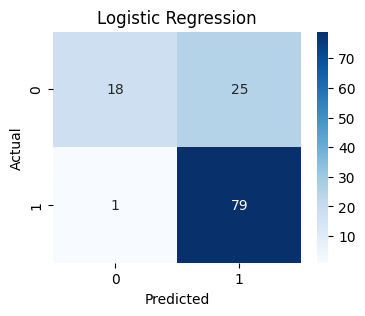

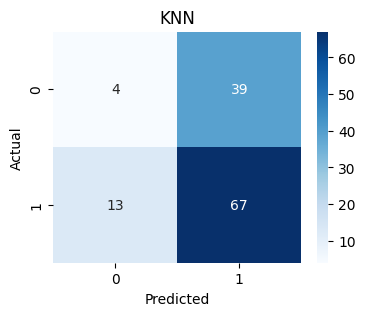

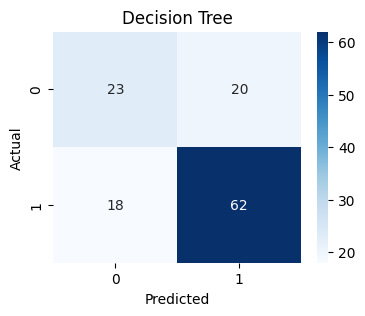

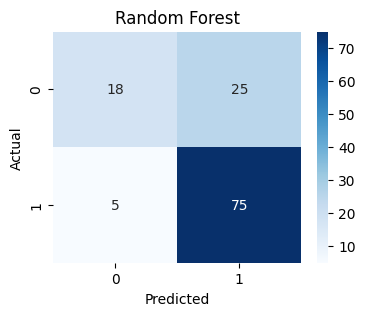

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [128]:
# Best Model
best_model = rf

#### Predict on Test Dataset

In [129]:
test_predictions = best_model.predict(test_data)

In [131]:
test_predictions = ['Y' if i == 1 else 'N' for i in test_predictions]

submission = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': test_predictions
})

submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,N


In [132]:
submission.to_csv("Loan_Prediction_Submission.csv", index=False)